SIFT-Based Object Detection using Feature Matching Title: Object Localization in a Scene using SIFT Feature Matching

In [ ]:
#install libraries
!pip install opencv-contrib-python --quiet


In [ ]:
#upload images
from google.colab import files
uploaded = files.upload()


Saving Template.png to Template.png
Saving Scene.png to Scene.png


In [ ]:
#import lib, load images
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
template = cv2.imread("Template.png")
scene = cv2.imread("Scene.png")

# Convert to grayscale
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)


In [ ]:
#detect sift keypoints and descriptors
# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(template_gray, None)
kp2, des2 = sift.detectAndCompute(scene_gray, None)

print(f"Template keypoints: {len(kp1)}")
print(f"Scene keypoints: {len(kp2)}")


Template keypoints: 384
Scene keypoints: 542


In [ ]:
#match descriptors
# Brute Force matcher
bf = cv2.BFMatcher()

# KNN matching
matches = bf.knnMatch(des1, des2, k=2)

# Apply Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Good matches after ratio test: {len(good_matches)}")


Good matches after ratio test: 97


In [ ]:
#homography estimation
if len(good_matches) > 10:
    # Extract matched keypoints
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

    # Compute homography
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # Get template corners
    h, w = template_gray.shape
    corners = np.float32([[0,0], [w,0], [w,h], [0,h]]).reshape(-1,1,2)

    # Transform corners into scene
    projected_corners = cv2.perspectiveTransform(corners, H)

    # Draw bounding box
    scene_detected = scene.copy()
    cv2.polylines(scene_detected, [np.int32(projected_corners)],
                  isClosed=True, color=(0,255,0), thickness=3)

else:
    print("Not enough good matches to compute homography.")
    scene_detected = scene.copy()


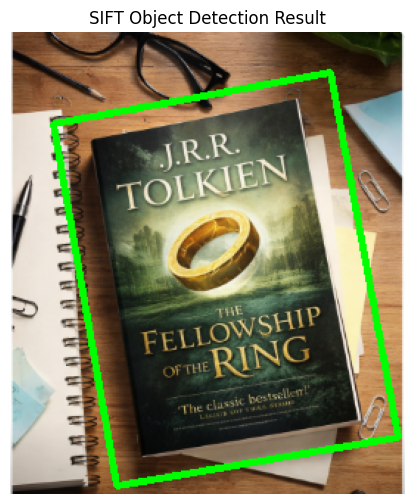

In [ ]:
#display result
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(scene_detected, cv2.COLOR_BGR2RGB))
plt.title("SIFT Object Detection Result")
plt.axis("off")
plt.show()
